# 08 — Stagnone di Marsala: Model Output Postprocessing

Compare model output at observation points with in-situ measurements:
- BocaNord (BN): northern inlet
- BocaSud (BS): southern inlet  
- AltavilaEst (AE): internal lagoon

**Model run:** July 1-10, 2025 (9 days), 3D with 10 sigma layers

## 1. Imports and paths

In [1]:
%matplotlib inline
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import xarray as xr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

project_root = Path(r'F:\StagnoneDT')
model_dir = project_root / 'model' / 'dflowfm'
output_dir = model_dir / 'output'
processed_dir = project_root / 'data' / 'processed'
figures_dir = project_root / 'figures'
os.makedirs(figures_dir, exist_ok=True)

## 2. Load model history file

In [2]:
his_file = output_dir / 'Stagnone_dxy01_15m_his.nc'
ds_his = xr.open_dataset(str(his_file))

print('History file loaded:')
print(f'  Time range: {ds_his.time.values[0]} to {ds_his.time.values[-1]}')
print(f'  Number of timesteps: {len(ds_his.time)}')
print(f'  Number of stations: {len(ds_his.station)}')
print(f'\nKey variables:')
for v in ['waterlevel', 'salinity', 'temperature', 'x_velocity', 'y_velocity']:
    if v in ds_his:
        print(f'  {v}: shape {ds_his[v].shape}')

History file loaded:
  Time range: 2025-07-01T00:00:00.000000000 to 2025-07-10T00:00:00.000000000
  Number of timesteps: 1297
  Number of stations: 18

Key variables:
  waterlevel: shape (1297, 18)
  salinity: shape (1297, 18, 10)
  temperature: shape (1297, 18, 10)
  x_velocity: shape (1297, 18, 10)
  y_velocity: shape (1297, 18, 10)


In [3]:
# List station names
station_names = [s.decode() if isinstance(s, bytes) else str(s) for s in ds_his.station_name.values]
print('Available observation stations:')
for i, name in enumerate(station_names):
    print(f'  [{i}] {name.strip()}')

Available observation stations:
  [0] gtsm3-era5-344-id_coast_glob_eur_00346
  [1] gtsm3-era5-345-id_coast_glob_eur_00347
  [2] gtsm3-era5-3030-id_coast_glob_eur_03037
  [3] gtsm3-era5-3031-id_coast_glob_eur_03038
  [4] gtsm3-era5-3032-id_coast_glob_eur_03039
  [5] gtsm3-era5-3033-id_coast_glob_eur_03040
  [6] gtsm3-era5-3034-id_coast_glob_eur_03041
  [7] gtsm3-era5-24696-id_reg_grid_eur_06067
  [8] gtsm3-era5-24697-id_reg_grid_eur_06068
  [9] gtsm3-era5-24745-id_reg_grid_eur_06118
  [10] gtsm3-era5-24746-id_reg_grid_eur_06119
  [11] gtsm3-era5-41619-islands_239627
  [12] gtsm3-era5-41620-islands_239643
  [13] gtsm3-era5-41625-islands_239680
  [14] AltaVilaEst
  [15] BocaNord
  [16] BocaSud
  [17] ObservationPoint01


## 3. Find indices for BocaNord, BocaSud, AltavilaEst

In [4]:
# Map station names to indices
target_stations = {
    'BocaNord': None,
    'BocaSud': None,
    'AltaVilaEst': None,  # note: model uses AltaVilaEst (no second 'a')
}

for i, name in enumerate(station_names):
    name_clean = name.strip()
    for key in target_stations:
        if key.lower() in name_clean.lower() or name_clean.lower() in key.lower():
            target_stations[key] = i

print('Found indices:')
for key, idx in target_stations.items():
    if idx is not None:
        print(f'  {key}: index {idx}, name in model = "{station_names[idx].strip()}"')
    else:
        print(f'  {key}: NOT FOUND')

Found indices:
  BocaNord: index 15, name in model = "BocaNord"
  BocaSud: index 16, name in model = "BocaSud"
  AltaVilaEst: index 14, name in model = "AltaVilaEst"


## 4. Load processed in-situ data

In [5]:
# Load 10-min processed in-situ data (UTC)
obs_data = {}
for name, file in [('BocaNord', 'wl_BocaNord_10min_UTC.csv'),
                    ('BocaSud', 'wl_BocaSud_10min_UTC.csv'),
                    ('AltaVilaEst', 'wl_AltavilaEst_10min_UTC.csv')]:
    csv_path = processed_dir / file
    if csv_path.exists():
        df = pd.read_csv(str(csv_path), index_col=0, parse_dates=True)
        df.columns = ['wl_obs']
        obs_data[name] = df
        print(f'  {name}: {len(df)} records, '
              f'{df.index[0]} to {df.index[-1]}, '
              f'mean={df.wl_obs.mean():.3f} m')
    else:
        print(f'  {name}: file not found ({csv_path})')

  BocaNord: 1297 records, 2025-06-30 23:00:00 to 2025-07-09 23:00:00, mean=0.073 m
  BocaSud: 1297 records, 2025-06-30 23:00:00 to 2025-07-09 23:00:00, mean=0.130 m
  AltaVilaEst: 1297 records, 2025-06-30 23:00:00 to 2025-07-09 23:00:00, mean=0.030 m


## 5. Extract model time series and align with observations

In [6]:
comparisons = {}

for name, idx in target_stations.items():
    if idx is None or name not in obs_data:
        continue
    
    # Model water level at this station
    model_wl = ds_his.waterlevel.isel(station=idx).to_pandas()
    model_wl.name = 'wl_model'
    
    # Observation water level
    obs_wl = obs_data[name]['wl_obs']
    
    # Align on common timestamps
    df = pd.concat([model_wl, obs_wl], axis=1).dropna()
    
    # Remove model spin-up (first 12 hours)
    spin_up_end = df.index[0] + pd.Timedelta(hours=12)
    df_calib = df[df.index >= spin_up_end].copy()
    
    # Compute residual (mean offset) — useful to see if there's a constant bias
    df_calib['residual'] = df_calib['wl_model'] - df_calib['wl_obs']
    
    comparisons[name] = df_calib
    print(f'{name}: {len(df_calib)} aligned records (after 12h spin-up)')

BocaNord: 1219 aligned records (after 12h spin-up)
BocaSud: 1219 aligned records (after 12h spin-up)
AltaVilaEst: 1219 aligned records (after 12h spin-up)


## 6. Compute validation metrics

In [7]:
def willmott_skill(obs, mod):
    """Willmott's index of agreement (d). 1 = perfect agreement."""
    obs = np.asarray(obs)
    mod = np.asarray(mod)
    obs_mean = obs.mean()
    num = np.sum((mod - obs) ** 2)
    den = np.sum((np.abs(mod - obs_mean) + np.abs(obs - obs_mean)) ** 2)
    return 1 - num / den

def compute_stats(obs, mod):
    return {
        'RMSE': np.sqrt(mean_squared_error(obs, mod)),
        'MAE': mean_absolute_error(obs, mod),
        'Bias': (mod - obs).mean(),
        'R2': r2_score(obs, mod),
        'Willmott_d': willmott_skill(obs, mod),
        'Corr': np.corrcoef(obs, mod)[0, 1],
        'Std_obs': obs.std(),
        'Std_mod': mod.std(),
    }

stats_table = []
for name, df in comparisons.items():
    stats = compute_stats(df['wl_obs'].values, df['wl_model'].values)
    stats['Station'] = name
    stats_table.append(stats)

stats_df = pd.DataFrame(stats_table).set_index('Station')
print('=== VALIDATION METRICS ===\n')
print(stats_df.to_string(float_format=lambda x: f'{x:.4f}'))

=== VALIDATION METRICS ===

              RMSE    MAE    Bias       R2  Willmott_d   Corr  Std_obs  Std_mod
Station                                                                        
BocaNord    0.4372 0.4323 -0.4323 -53.4431      0.2241 0.9391   0.0593   0.1180
BocaSud     0.4517 0.4505 -0.4505 -71.9509      0.1648 0.7827   0.0529   0.0491
AltaVilaEst 0.3823 0.3798 -0.3798 -41.4906      0.2091 0.7051   0.0586   0.0532


## 7. Time series comparison plots

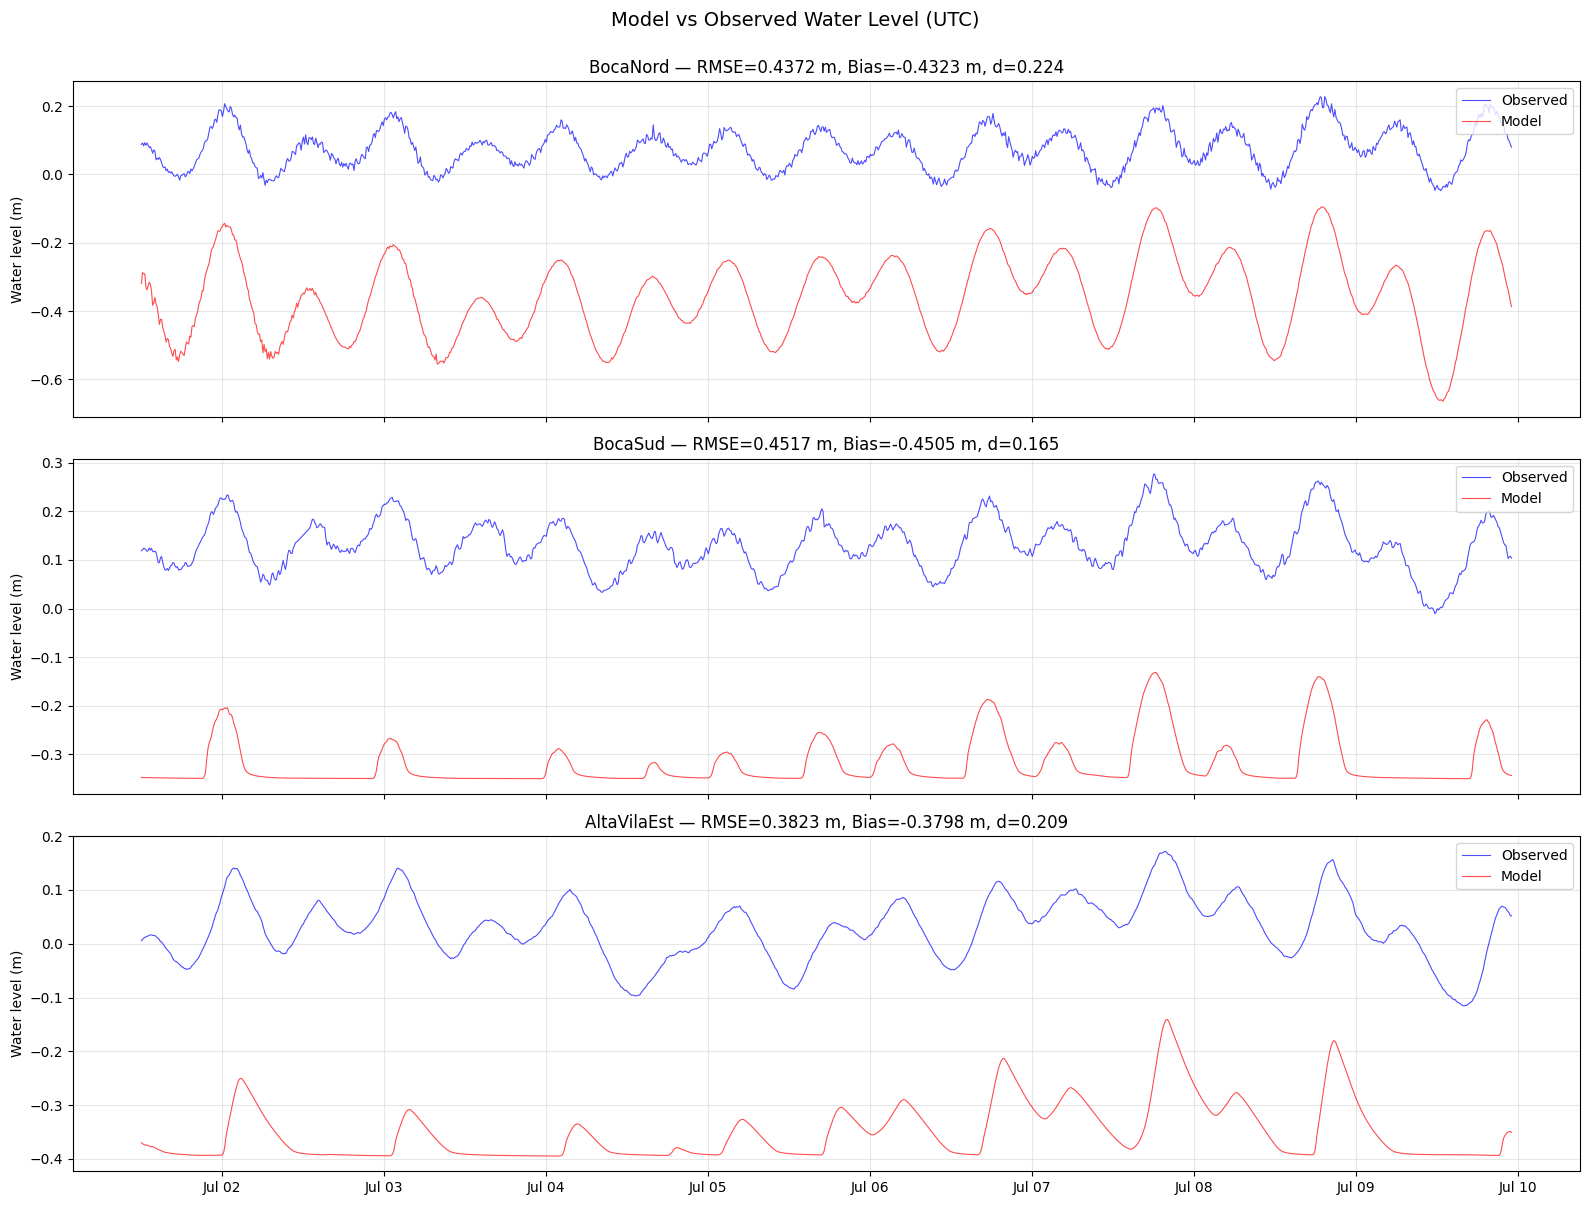

In [8]:
n_stations = len(comparisons)
fig, axes = plt.subplots(n_stations, 1, figsize=(16, 4 * n_stations), sharex=True)
if n_stations == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, comparisons.items()):
    ax.plot(df.index, df['wl_obs'], 'b-', linewidth=0.8, alpha=0.7, label='Observed')
    ax.plot(df.index, df['wl_model'], 'r-', linewidth=0.8, alpha=0.7, label='Model')
    ax.set_ylabel('Water level (m)')
    ax.set_title(f'{name} — RMSE={stats_df.loc[name, "RMSE"]:.4f} m, '
                  f'Bias={stats_df.loc[name, "Bias"]:.4f} m, '
                  f'd={stats_df.loc[name, "Willmott_d"]:.3f}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.suptitle('Model vs Observed Water Level (UTC)', fontsize=14, y=1.0)
fig.tight_layout()
plt.savefig(str(figures_dir / 'model_vs_obs_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Scatter plots and residuals

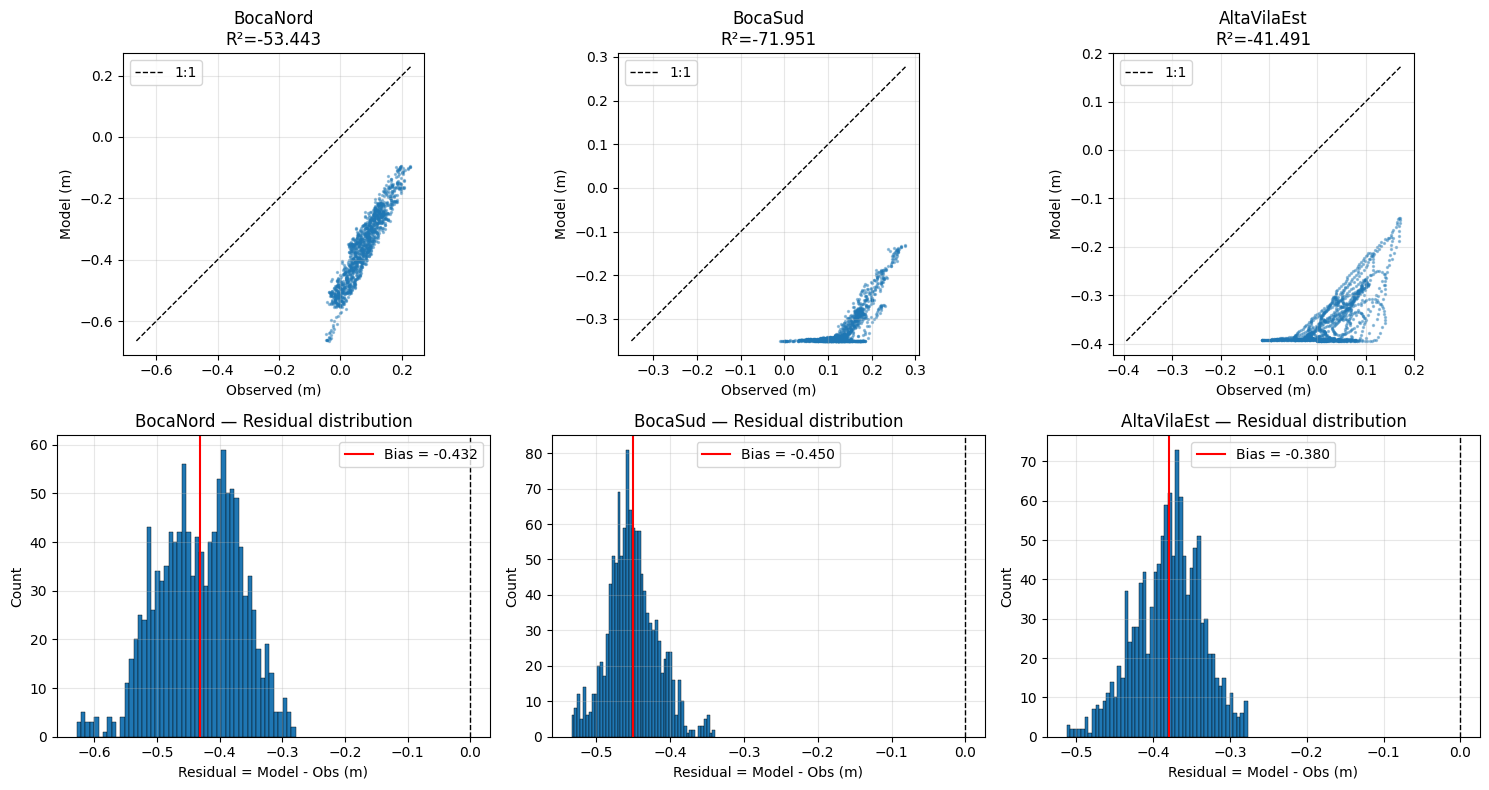

In [9]:
fig, axes = plt.subplots(2, n_stations, figsize=(5 * n_stations, 8))
if n_stations == 1:
    axes = axes.reshape(2, 1)

for col, (name, df) in enumerate(comparisons.items()):
    # Scatter plot
    ax = axes[0, col]
    ax.scatter(df['wl_obs'], df['wl_model'], s=2, alpha=0.4)
    lim_min = min(df['wl_obs'].min(), df['wl_model'].min())
    lim_max = max(df['wl_obs'].max(), df['wl_model'].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1, label='1:1')
    ax.set_xlabel('Observed (m)')
    ax.set_ylabel('Model (m)')
    ax.set_title(f'{name}\nR²={stats_df.loc[name, "R2"]:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Residual histogram
    ax = axes[1, col]
    ax.hist(df['residual'], bins=50, edgecolor='black', linewidth=0.3)
    ax.axvline(0, color='k', linestyle='--', linewidth=1)
    ax.axvline(stats_df.loc[name, 'Bias'], color='r', linewidth=1.5,
                label=f'Bias = {stats_df.loc[name, "Bias"]:.3f}')
    ax.set_xlabel('Residual = Model - Obs (m)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — Residual distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig(str(figures_dir / 'model_vs_obs_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. 3D vertical structure check

Verify the wind-driven surface vs bottom flow structure that motivates the 3D approach.

Velocity dimensions: ('time', 'laydim'), shape: (1297, 10)
Sigma layers: 10


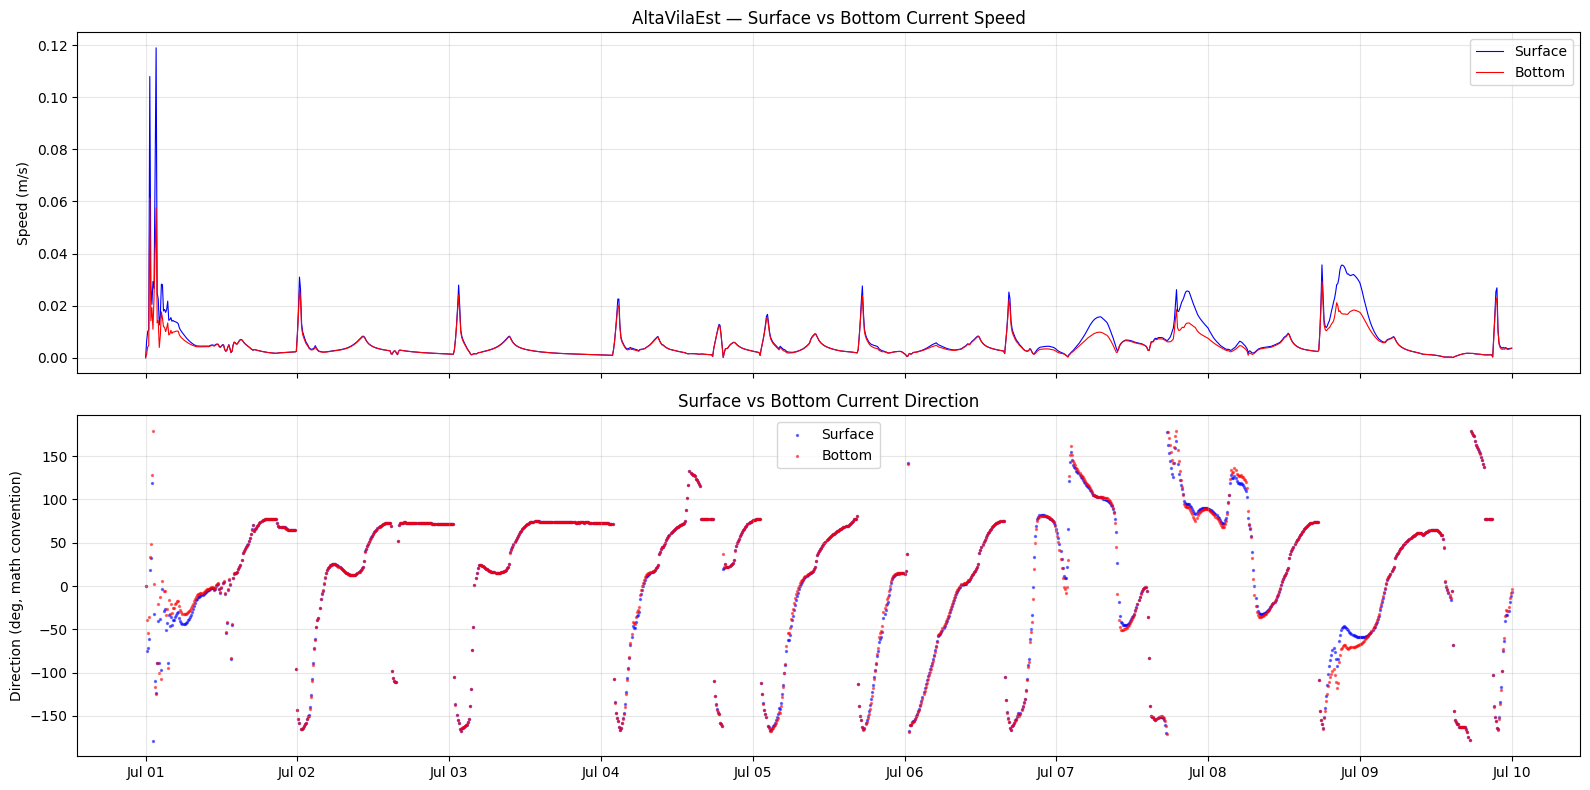


Vertical shear analysis (AltaVilaEst):
  Mean surface speed: 0.0060 m/s
  Mean bottom speed:  0.0049 m/s
  Ratio (surf/bot):   1.24


In [10]:
# Check vertical velocity structure at one of the lagoon-internal stations (AltaVilaEst)
ae_idx = target_stations.get('AltaVilaEst')

if ae_idx is not None and 'x_velocity' in ds_his:
    # Get u and v at all sigma layers for this station
    u = ds_his.x_velocity.isel(station=ae_idx)
    v = ds_his.y_velocity.isel(station=ae_idx)
    
    print(f'Velocity dimensions: {u.dims}, shape: {u.shape}')
    print(f'Sigma layers: {u.shape[-1] if len(u.shape) > 1 else "none (2D)"}')
    
    # If 3D, plot surface vs bottom velocity over time
    if len(u.shape) > 1 and u.shape[-1] > 1:
        n_layers = u.shape[-1]
        # Surface = top sigma layer, bottom = bottom sigma layer
        u_surf = u.isel({u.dims[-1]: -1}).values
        v_surf = v.isel({v.dims[-1]: -1}).values
        u_bot = u.isel({u.dims[-1]: 0}).values
        v_bot = v.isel({v.dims[-1]: 0}).values
        
        speed_surf = np.sqrt(u_surf ** 2 + v_surf ** 2)
        speed_bot = np.sqrt(u_bot ** 2 + v_bot ** 2)
        
        fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
        
        ax = axes[0]
        ax.plot(u.time.values, speed_surf, 'b-', linewidth=0.8, label='Surface')
        ax.plot(u.time.values, speed_bot, 'r-', linewidth=0.8, label='Bottom')
        ax.set_ylabel('Speed (m/s)')
        ax.set_title('AltaVilaEst — Surface vs Bottom Current Speed')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Direction difference
        ax = axes[1]
        dir_surf = np.degrees(np.arctan2(v_surf, u_surf))
        dir_bot = np.degrees(np.arctan2(v_bot, u_bot))
        ax.scatter(u.time.values, dir_surf, c='blue', s=2, alpha=0.5, label='Surface')
        ax.scatter(u.time.values, dir_bot, c='red', s=2, alpha=0.5, label='Bottom')
        ax.set_ylabel('Direction (deg, math convention)')
        ax.set_title('Surface vs Bottom Current Direction')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        
        fig.tight_layout()
        plt.savefig(str(figures_dir / 'vertical_structure_AE.png'), dpi=150, bbox_inches='tight')
        plt.show()
        
        # Statistics on shear
        print(f'\nVertical shear analysis (AltaVilaEst):')
        print(f'  Mean surface speed: {speed_surf.mean():.4f} m/s')
        print(f'  Mean bottom speed:  {speed_bot.mean():.4f} m/s')
        print(f'  Ratio (surf/bot):   {speed_surf.mean() / speed_bot.mean():.2f}')
    else:
        print('Velocity output is 2D depth-averaged — no vertical structure available.')
else:
    print('Velocity not in his file or AltaVilaEst not found.')

## 10. Salinity and temperature check

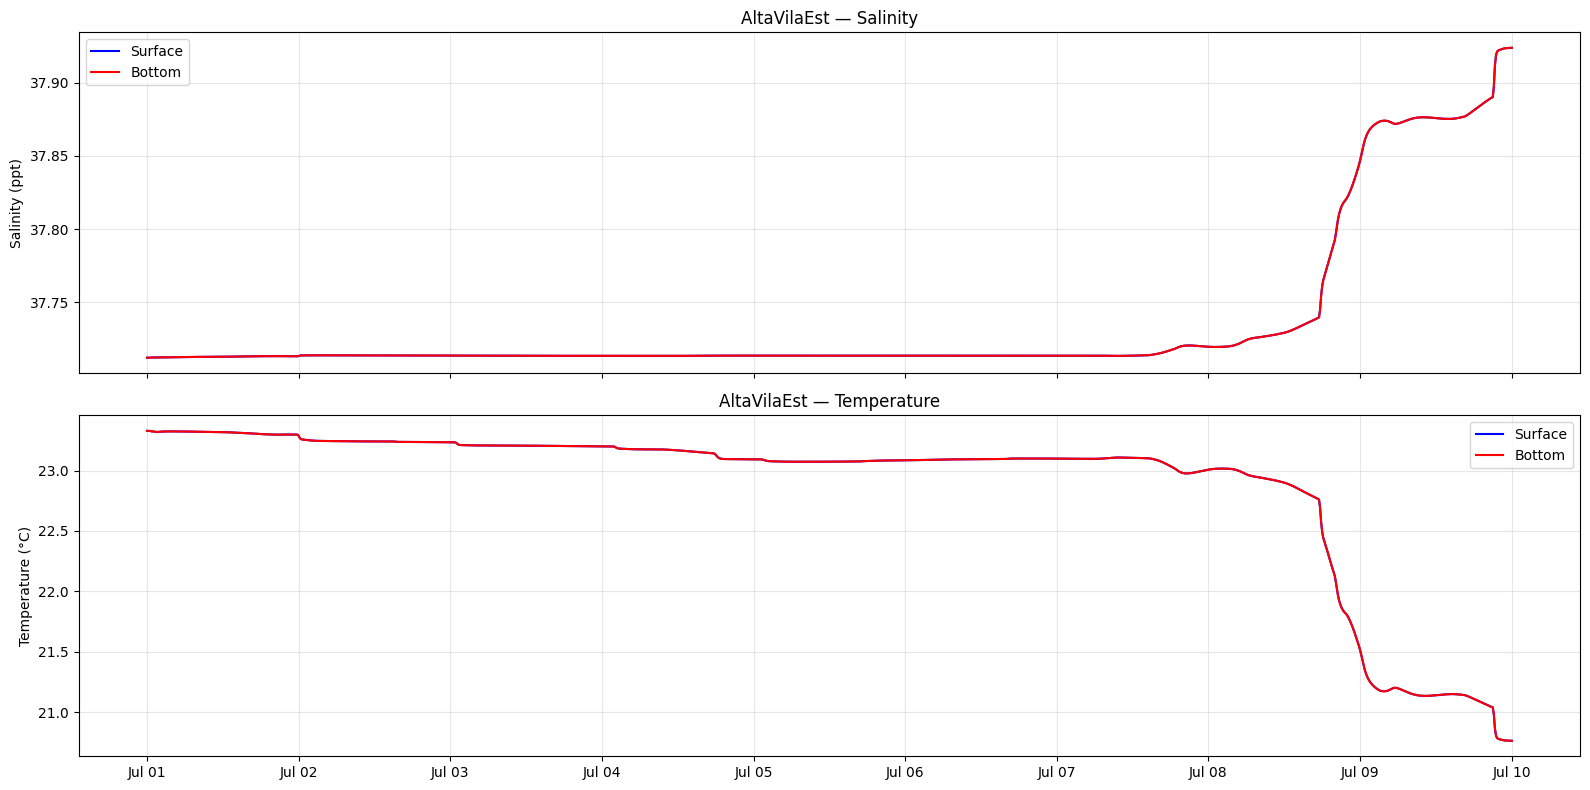

In [11]:
# Plot salinity and temperature at AltaVilaEst (vertical profile evolution)
ae_idx = target_stations.get('AltaVilaEst')

if ae_idx is not None and 'salinity' in ds_his and 'temperature' in ds_his:
    sal = ds_his.salinity.isel(station=ae_idx)
    tem = ds_his.temperature.isel(station=ae_idx)
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    
    if len(sal.shape) > 1 and sal.shape[-1] > 1:
        # 3D: plot top vs bottom
        axes[0].plot(sal.time.values, sal.isel({sal.dims[-1]: -1}).values, 'b-', label='Surface')
        axes[0].plot(sal.time.values, sal.isel({sal.dims[-1]: 0}).values, 'r-', label='Bottom')
        axes[1].plot(tem.time.values, tem.isel({tem.dims[-1]: -1}).values, 'b-', label='Surface')
        axes[1].plot(tem.time.values, tem.isel({tem.dims[-1]: 0}).values, 'r-', label='Bottom')
    else:
        axes[0].plot(sal.time.values, sal.values, 'b-')
        axes[1].plot(tem.time.values, tem.values, 'r-')
    
    axes[0].set_ylabel('Salinity (ppt)')
    axes[0].set_title('AltaVilaEst — Salinity')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_ylabel('Temperature (°C)')
    axes[1].set_title('AltaVilaEst — Temperature')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    
    fig.tight_layout()
    plt.savefig(str(figures_dir / 'salinity_temperature_AE.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 11. Summary

Save metrics table and key observations for the calibration phase.

In [12]:
# Save metrics to CSV
metrics_csv = processed_dir / 'validation_metrics_v01.csv'
stats_df.to_csv(str(metrics_csv))
print(f'Metrics saved to: {metrics_csv}\n')
print(stats_df.to_string(float_format=lambda x: f'{x:.4f}'))

print('\n=== INTERPRETATION ===')
for name, row in stats_df.iterrows():
    print(f'\n{name}:')
    print(f'  RMSE = {row["RMSE"]:.3f} m {"(target < 0.05)" if row["RMSE"] > 0.05 else "OK"}')
    print(f'  Bias = {row["Bias"]:.3f} m {"(needs correction)" if abs(row["Bias"]) > 0.02 else "OK"}')
    print(f'  Willmott d = {row["Willmott_d"]:.3f} {"(good if > 0.9)" if row["Willmott_d"] < 0.9 else "GOOD"}')
    print(f'  Std obs/mod = {row["Std_obs"]:.3f} / {row["Std_mod"]:.3f} m')

Metrics saved to: F:\StagnoneDT\data\processed\validation_metrics_v01.csv

              RMSE    MAE    Bias       R2  Willmott_d   Corr  Std_obs  Std_mod
Station                                                                        
BocaNord    0.4372 0.4323 -0.4323 -53.4431      0.2241 0.9391   0.0593   0.1180
BocaSud     0.4517 0.4505 -0.4505 -71.9509      0.1648 0.7827   0.0529   0.0491
AltaVilaEst 0.3823 0.3798 -0.3798 -41.4906      0.2091 0.7051   0.0586   0.0532

=== INTERPRETATION ===

BocaNord:
  RMSE = 0.437 m (target < 0.05)
  Bias = -0.432 m (needs correction)
  Willmott d = 0.224 (good if > 0.9)
  Std obs/mod = 0.059 / 0.118 m

BocaSud:
  RMSE = 0.452 m (target < 0.05)
  Bias = -0.450 m (needs correction)
  Willmott d = 0.165 (good if > 0.9)
  Std obs/mod = 0.053 / 0.049 m

AltaVilaEst:
  RMSE = 0.382 m (target < 0.05)
  Bias = -0.380 m (needs correction)
  Willmott d = 0.209 (good if > 0.9)
  Std obs/mod = 0.059 / 0.053 m
